In [ ]:
#K-medias es un algoritmo de agrupamiento por particiones cuyo objetivo es separar los objetos
#en K conjuntos disjuntos minimizando la suma de distancias al cuadrado de los objetos
#de cada grupo. 
#Importamos los datos
import pandas as pd
url_datos = 'https://drive.google.com/uc?id=1OzVlp4RsT63W6d18_Zc5WmUonLXMDNL8'
mexpr = pd.read_csv(url_datos, delimiter='\t')
mexpr_toy = mexpr.iloc[0:49, 0:19] #Coger un conjunto pequeño de los datos

In [5]:
#Importamos librerias y definimos el algoritmo y sus parámetros
from sklearn.cluster import KMeans
from sklearn import metrics, preprocessing

k_means = KMeans(n_clusters=3)  #el n. de clusters es relevante para el resultado
datos = mexpr_toy.transpose()   #primero transponemos la matriz
cluster_predict=k_means.fit_predict(datos)

#añadimos el resultado a una tabla para qeu sea mas manejable
clusters = pd.DataFrame(cluster_predict, index=datos.index, columns=['cluster'])
clusters

,cluster
TCGA-D9-A4Z6-06,2
TCGA-EE-A2MQ-06,0
TCGA-EE-A3AF-06,0
TCGA-ER-A19F-06,0
TCGA-EE-A2MF-06,0
TCGA-EE-A2MJ-06,2
TCGA-BF-AAP4-01,2
TCGA-D3-A8GM-06,2
TCGA-GN-A26A-06,0
TCGA-EB-A3XE-01,1


In [ ]:
#Ver el tamaño de cada cluster
print("Tamaño de cada cluster")
size=clusters['cluster'].value_counts()
size

Tamaño de cada cluster


cluster
2    9
0    7
1    3
Name: count, dtype: int64

<Axes: >

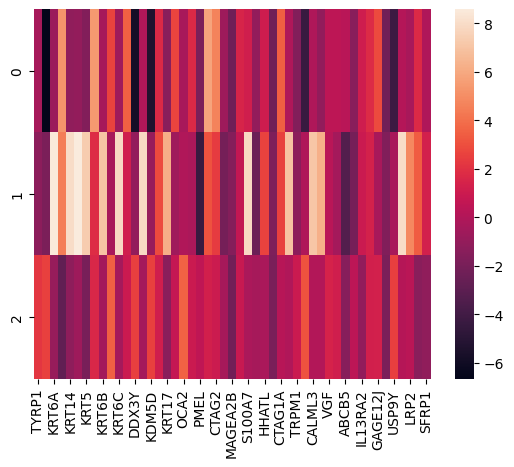

In [8]:
#Visualizar los perfiles de expresión genética
import seaborn as sns
centers=pd.DataFrame(k_means.cluster_centers_, columns=list(datos))
sns.heatmap(centers)